# Linear Regression Model

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Training and Validation Data

In [6]:
# Load the training and validation datasets
df_train = pd.read_csv('gs://aura_datasets_training_validation/AURA_aug_sep_60k.csv')
df_val   = pd.read_csv('gs://aura_datasets_training_validation/AURA_validation_sep_12k.csv')

# Define feature and target columns
feature_cols = ['noise_db', 'light_lux', 'crowd_count']
target_col   = 'discomfort_level'

# Separate features and target
X_train = df_train[feature_cols]
y_train = df_train[target_col]

X_val = df_val[feature_cols]
y_val = df_val[target_col]

# Display first few rows of X_train
X_train.head()


,noise_db,light_lux,crowd_count
0,44.6,395,8
1,60.1,689,19
2,69.5,548,13
3,32.0,120,1
4,34.3,120,1


## Preprocess the Features

In [7]:
# Define the numeric transformer
numeric_features = feature_cols
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# ColumnTransformer applies the scaler to numeric features
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='drop'
)


## Build and Train the Linear Regression Model

In [9]:
# Initialize linear regression model
lin_reg = ElasticNet()

# Build the pipeline
lin_pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', lin_reg)
])

# Grid search for optimal parameters
param_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1],
    "model__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0]
}

grid_search = GridSearchCV(
    estimator=lin_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=0
)

# Fit on training data
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV neg_mae:", grid_search.best_score_)

# Extract best model
best_pipe = grid_search.best_estimator_

/home/steven/.pyenv/versions/Aura/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.090e+01, tolerance: 3.013e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/steven/.pyenv/versions/Aura/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.107e+01, tolerance: 3.014e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemente

Best params: {'model__alpha': 0.1, 'model__l1_ratio': 0.0}
Best CV neg_mae: -0.022797421625792715


/home/steven/.pyenv/versions/Aura/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.063e+02, tolerance: 3.773e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


## Evaluate the Linear Regression Model

Mean Absolute Error: 0.0229
Mean Squared Error: 0.0010
R² Score: 0.9845


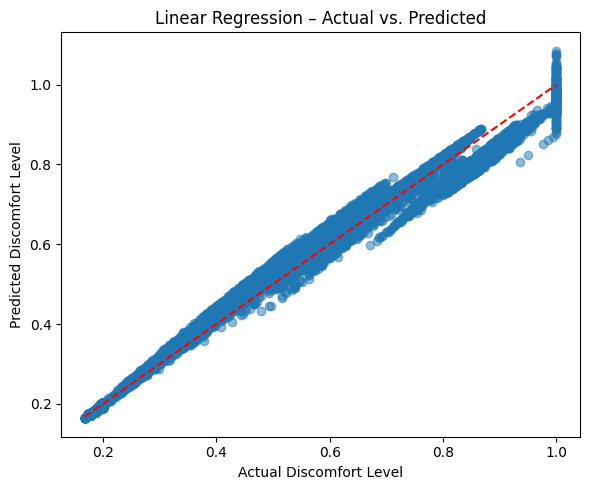

In [10]:
# Predict on validation set
y_val_pred = best_pipe.predict(X_val)

# Compute evaluation metrics
mae = mean_absolute_error(y_val, y_val_pred)
mse = mean_squared_error(y_val, y_val_pred)
r2  = r2_score(y_val, y_val_pred)
print(f'Mean Absolute Error: {mae:.4f}')
print(f'Mean Squared Error: {mse:.4f}')
print(f'R² Score: {r2:.4f}')

# Plot actual vs predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_val, y_val_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Actual Discomfort Level')
plt.ylabel('Predicted Discomfort Level')
plt.title('Linear Regression – Actual vs. Predicted')
plt.tight_layout()
plt.show()


## Learning Curve

/home/steven/.pyenv/versions/Aura/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.577e+00, tolerance: 3.083e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/steven/.pyenv/versions/Aura/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.517e+00, tolerance: 3.005e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemente

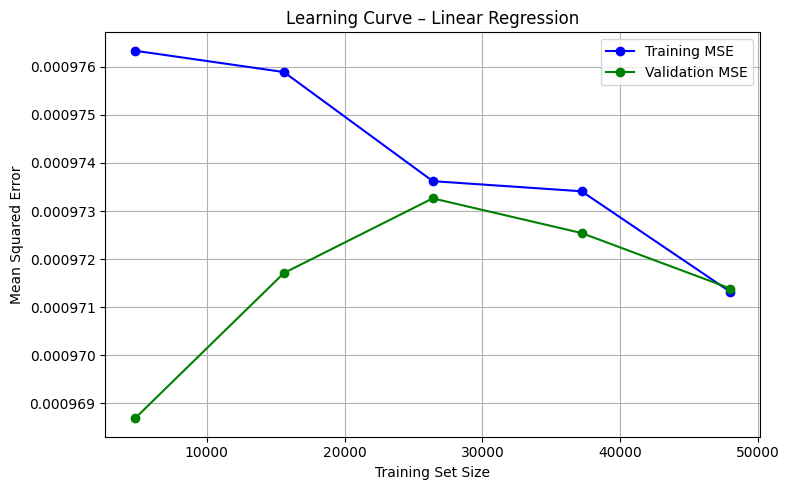

In [12]:
# Compute learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_pipe,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 5),
    shuffle=True,
    n_jobs=-1
)

# Convert to positive MSE
train_mse = -train_scores
val_mse   = -val_scores

# Compute means and stds
train_mean = train_mse.mean(axis=1)
train_std  = train_mse.std(axis=1)
val_mean   = val_mse.mean(axis=1)
val_std    = val_mse.std(axis=1)

# Plot learning curve
plt.figure(figsize=(8, 5))
plt.title('Learning Curve – Linear Regression')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')

plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training MSE')

plt.plot(train_sizes, val_mean, 'o-', color='green', label='Validation MSE')

plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()
